# Analyse multidimensionnelle des trajectoires de soins : Jeu de données VICAN

Ce notebook présente l'exploration des hyperparamètres de la méthode SWoTTeD sur un jeu de données de trajectoires oncologiques (1 336 patients, 4 types de traitements, suivi en mois).
L'objectif est d'identifier une configuration produisant à la fois une bonne qualité de reconstruction (FIT_X) et des phénotypes temporels cliniquement interprétables.

## Sommaire

1. Imports et configuration de l'environnement
2. Chargement et préparation des données
3. Initialisation du modèle TCA et construction du tenseur
4. Exploration des hyperparamètres de SWoTTeD
   - 4.1. Variation du rang $R$ et de la taille de fenêtre $\omega$ (sans early stopping, lr=1e-2)
   - 4.2. Réduction du taux d'apprentissage avec early stopping (lr $\in$ {5e-5, 1e-4})
   - 4.3. Ajustement des termes de régularisation : faibles pénalités
   - 4.4. Ajustement des termes de régularisation : fortes pénalités
5. Clustering sur les intensités des phénotypes

## 1. Imports


### 1.1. Librairies

In [2]:
from pathlib import Path
import sys
import time
import itertools

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn.functional as F

# Chargement du package TCA

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "trajectoryclusteringanalysis").exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver la racine du projet depuis {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis.tca import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Package chargé depuis : {src_path}")

Package chargé depuis : c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


### 1.2. Fonctions

Pour faciliter la suite, on implémente les fonctions suivantes :
- `run_swotted_trial` : fonction d'entraînement
- `plot_training_history` : pour visualiser la courbe d'entraînement (`train_loss` et $\text{FIT}_X$)
- `phenotype_diversity` : pour vérifier qu'on n'a pas de redondance dans les phénotypes

La fonction `phenotype_diversity` est telle que :

Pour chaque paire de phénotypes $(i, j)$, on calcule :
$$d_{\cos}(\mathcal{P}_i, \mathcal{P}_j) = 1 - \frac{\langle \tilde{p}_i, \tilde{p}_j \rangle}{\|\tilde{p}_i\| \cdot \|\tilde{p}_j\|}$$

où $\tilde{p}_r$ est le vecteur aplati et normalisé du phénotype $\mathcal{P}_r$.
La diversité globale est la moyenne sur toutes les paires $(i < j)$ :

$$\text{div}(\mathcal{P}) = \binom{R}{2}^{-1} \sum_{1 \leq i < j \leq R} d_{\cos}(\mathcal{P}_i, \mathcal{P}_j)$$

Une valeur proche de $0$ indique desphénotypes quasi identiques ;
une valeur proche de $1$ indique des phénotypes bien distincts (diversité maximale).

In [6]:
def run_swotted_trial(
    timed_event_structure: pd.DataFrame,
    rank: int,
    time_window_length: int,
    reg_ns: float,
    reg_s: float,
    lr: float,
    n_epochs: int,
    metric: str = 'Bernoulli',
    early_stopping: bool = True,
    early_stopping_patience: int = 10,
    early_stopping_min_delta: float = 1e-4,
    fit_metric_every_n_epochs: int = 10,
    fit_metric_eval_max_patients: int = 64,
    num_workers: int = 0,
) -> dict:
    """Entraîne un modèle SWoTTeD pour une configuration donnée et retourne les résultats.

    Parameters
    ----------
    timed_event_structure : pd.DataFrame
        Données au format long (ID_PATIENT, Time, Event).
    rank : int
        Nombre de phénotypes R.
    time_window_length : int
        Taille de la fenêtre temporelle ω.
    reg_ns : float
        Terme de régularisation de non-succession.
    reg_s : float
        Terme de régularisation de sparsité.
    lr : float
        Taux d'apprentissage.
    n_epochs : int
        Nombre maximum d'epochs.
    metric : str
        Fonction de perte ('Bernoulli' par défaut).
    early_stopping : bool
        Active ou désactive l'early stopping.
    early_stopping_patience : int
        Nombre d'epochs sans amélioration avant arrêt.
    early_stopping_min_delta : float
        Amélioration minimale de FIT_X pour réinitialiser la patience.
    fit_metric_every_n_epochs : int
        Fréquence de calcul de FIT_X approximée.
    fit_metric_eval_max_patients : int
        Nombre de patients utilisés pour l'approximation de FIT_X.
    num_workers : int
        Nombre de workers pour le DataLoader.

    Returns
    -------
    dict
        Dictionnaire contenant les paramètres, les métriques et l'objet tca_trial entraîné.
    """
    print('\n' + '=' * 90)
    print(f"rank={rank}, twl={time_window_length}, reg_ns={reg_ns}, "
          f"reg_s={reg_s}, learning_rate={lr}")

    tca_trial = TCA(
        data=timed_event_structure,
        index_col='ID_PATIENT',
        time_col='Time',
        event_col='Event',
        mode='multidimensional',
    )
    tca_trial.analyzer.transform_time_event_structure_to_tensor()
    tensor_trial = tca_trial.analyzer.get_tensor()

    t0 = time.perf_counter()
    tca_trial.analyzer.fit_swotted_decomposition(
        tensor_trial,
        rank,
        time_window_length,
        reg_ns,
        reg_s,
        metric,
        lr,
        n_epochs,
        fit_metric_every_n_epochs=fit_metric_every_n_epochs,
        fit_metric_eval_max_patients=fit_metric_eval_max_patients,
        restore_best_fit_checkpoint=early_stopping,
        num_workers=num_workers,
        early_stopping_patience=early_stopping_patience if early_stopping else None,
        early_stopping_min_delta=early_stopping_min_delta,
        early_stopping_monitor='fit_metric',
    )
    elapsed = time.perf_counter() - t0

    hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
    best_fit       = hist.get('best_fit_metric', None)
    best_fit_epoch = hist.get('best_fit_metric_epoch', None)
    final_fit      = hist.get('final_fit_metric', None)
    epochs_run     = len(hist.get('epoch', []))

    print(f"  best_fit_metric={best_fit:.4f}, final_fit_metric={final_fit:.4f}, "
          f"epochs={epochs_run}, temps={elapsed:.1f}s")

    return {
        'rank':              rank,
        'time_window_length': time_window_length,
        'reg_term_ns':       reg_ns,
        'reg_term_s':        reg_s,
        'learning_rate':     lr,
        'epochs_run':        epochs_run,
        'best_fit_metric':   best_fit,
        'best_fit_epoch':    best_fit_epoch,
        'final_fit_metric':  final_fit,
        'elapsed_s':         round(elapsed, 2),
        'tca_trial':         tca_trial,
    }


def build_results_df(results: list) -> pd.DataFrame:
    """Convertit une liste de résultats en DataFrame trié par meilleur FIT_X décroissant."""
    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values(
            by=['best_fit_metric', 'final_fit_metric'],
            ascending=False,
            na_position='last'
        ).reset_index(drop=True)
    return df

In [7]:
def plot_training_history(row, title_suffix=""):
    """Affiche la courbe d'entraînement (train_loss + FIT_X approx.) pour une configuration.
    
    Parameters
    ----------
    row : dict ou pd.Series
        Ligne du DataFrame de résultats contenant 'tca_trial' et les métadonnées.
    title_suffix : str
        Suffixe optionnel ajouté au titre du graphique.
    """
    tca_trial = row['tca_trial']
    history = getattr(tca_trial.analyzer, 'training_history', None)

    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("Aucun historique d'entraînement disponible.")

    epochs          = history['epoch']
    train_loss      = history['train_loss_total']
    fit_epochs      = history['fit_metric_points_epoch']
    fit_values      = history['fit_metric_points_value']

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(epochs, train_loss, color='tab:blue', linewidth=2, label='train_loss_total')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('train_loss_total', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    if fit_epochs:
        ax2.plot(fit_epochs, fit_values, color='tab:green',
                 marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0:
                y_offset = 10 if i % 4 == 0 else -15
                ax2.annotate(f"{y:.4f}", (x, y),
                             textcoords='offset points',
                             xytext=(0, y_offset),
                             ha='center', fontsize=9)
        fit_min, fit_max = min(fit_values), max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(fit_min - 0.05 * fit_span, fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(lines, labels, loc='best')

    cfg = (f"R={row['rank']}, ω={row['time_window_length']}, "
           f"α={row['reg_term_s']}, γ={row['reg_term_ns']}, "
           f"lr={row['learning_rate']}")
    plt.title(f"Training — {cfg}{(' — ' + title_suffix) if title_suffix else ''}")
    plt.tight_layout()
    plt.show()

In [8]:
def phenotype_diversity(Ph_tensor: torch.Tensor, eps: float = 1e-12):
    """Calcule la diversité cosinus moyenne entre les R phénotypes.

    Parameters
    ----------
    Ph_tensor : torch.Tensor
        Tenseur de forme (R, N, w).
    eps : float
        Valeur pour la stabilité numérique lors de la normalisation.

    Returns
    -------
    div_value : float
        Diversité moyenne 1 - cosinus, dans [0, 1].
    pairwise_div : torch.Tensor
        Matrice de diversité par paires de forme (R, R), diagonale à 0.
    """
    if not isinstance(Ph_tensor, torch.Tensor):
        Ph_tensor = torch.as_tensor(Ph_tensor, dtype=torch.float32)

    if Ph_tensor.ndim != 3:
        raise ValueError(f"Forme attendue (R, N, w), reçu {tuple(Ph_tensor.shape)}")

    R = Ph_tensor.shape[0]
    if R < 2:
        return 0.0, torch.zeros((R, R), dtype=Ph_tensor.dtype, device=Ph_tensor.device)

    # Aplatissement (N, w) → vecteur R^(N*w) puis normalisation L2
    P = Ph_tensor.reshape(R, -1).float()
    P = F.normalize(P, p=2, dim=1, eps=eps)

    # Matrice de similarité cosinus
    cos_sim = P @ P.T

    # Matrice de diversité : 1 - cos(P_i, P_j)
    pairwise_div = 1.0 - cos_sim
    pairwise_div.fill_diagonal_(0.0)

    # Moyenne sur les paires (i < j)
    upper_idx = torch.triu_indices(R, R, offset=1, device=pairwise_div.device)
    div_value = pairwise_div[upper_idx[0], upper_idx[1]].mean().item()

    return div_value, pairwise_div


def print_diversity(row):
    """Affiche la diversité phénotypique et la matrice par paires pour une configuration."""
    tca_trial = row['tca_trial']
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()
    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Diversité phénotypique (moyenne 1 - cosinus) : {div_value:.6f}\n")

    R = pairwise_div.shape[0]
    col_names = [f"Phénotype_{i+1}" for i in range(R)]
    df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )
    display(df)

## 2. Chargement et préparation des données

### 2.1. Chargement

Le jeu de données est au format long : chaque ligne correspond à l'occurrence d'un événementpour un patient à un instant donné. 
Les quatre types d'événements sont : chirurgie, chimiothérapie IV, chimiothérapie per os et radiothérapie.

In [9]:
df = pd.read_csv(project_root / "data" / "multidimensional_data.csv")
print(f"Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Colonnes   : {list(df.columns)}")
df.head()

Dimensions : 20435 lignes, 3 colonnes
Colonnes   : ['PATIENT_ID', 'EVENT', 'TIME']


,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3


### 2.2. Encodage des événements

Les labels des événements sont encodés en entiers pour être passés au modèle TCA. On conserve `noms_events` pour les visualisations.

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()
timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']

noms_events = label_encoder.classes_
print(f"Événements encodés : {list(noms_events)}")
timed_event_structure.head()

Événements encodés : ['Chimiothérapie IV', 'Chimiothérapie per os', 'Chirurgie', 'Radiothérapie']


,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0


### 2.3. Statistiques descriptives

In [15]:
n_patients = timed_event_structure['ID_PATIENT'].nunique()
n_events   = timed_event_structure['Event'].nunique()
duree_max  = timed_event_structure['Time'].max()
duree_moy  = timed_event_structure.groupby('ID_PATIENT')['Time'].max().mean()

print(f"Nombre de patients         : {n_patients}")
print(f"Nombre de types d'événements : {n_events}")
print(f"Durée maximale de suivi    : {duree_max} mois")
print(f"Durée moyenne de suivi     : {duree_moy:.1f} mois")

Nombre de patients         : 1336
Nombre de types d'événements : 4
Durée maximale de suivi    : 23 mois
Durée moyenne de suivi     : 7.6 mois


In [17]:
# Patients ayant reçu les 4 types de traitements au moins une fois
all_events = set(timed_event_structure['Event'].unique())
patients_complets = (
    timed_event_structure
    .groupby('ID_PATIENT')
    .filter(lambda g: set(g['Event']) == all_events)
    ['ID_PATIENT'].unique()
)
print(f"Nombre de patients ayant reçu les {len(all_events)} traitements : {len(patients_complets)}")

Nombre de patients ayant reçu les 4 traitements : 50


## 3. Initialisation du modèle TCA et du tenseur

### 3.1. Initialisation du modèle TCA

On instancie le modèle TCA en mode multidimensionnel en lui passant le jeu de données.

In [18]:
tca = TCA(
    data=timed_event_structure,
    index_col='ID_PATIENT',
    alphabet=noms_events,
    states=noms_events,
    time_col='Time',
    event_col='Event',
    mode='multidimensional',
)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
                 alphabet                  label  label encoded
0      Chimiothérapie IV      Chimiothérapie IV              1
1  Chimiothérapie per os  Chimiothérapie per os              2
2              Chirurgie              Chirurgie              3
3          Radiothérapie          Radiothérapie              4


### 3.2. Construction du tenseur

Les données sont converties en tenseur  de dimension $K \times n \times T_k$ (patients × événements × temps).

In [19]:
tca.analyzer.transform_time_event_structure_to_tensor()
tensor = tca.analyzer.get_tensor()

shape = tca.analyzer.get_tensor_shape()
print(f"Nombre de patients  : {shape[0]}")
print(f"Nombre d'événements : {shape[1]}")
print(f"Durée maximale      : {shape[2]} mois")

Nombre de patients  : 1336
Nombre d'événements : 4
Durée maximale      : 24 mois


### 3.3. Visualisation d'une trajectoire individuelle

On visualise la matrice d'un patient ayant reçu les 4 types de traitements, afin de vérifier que le tenseur a bien été construit.

Patient utilisé pour la visualisation : 8


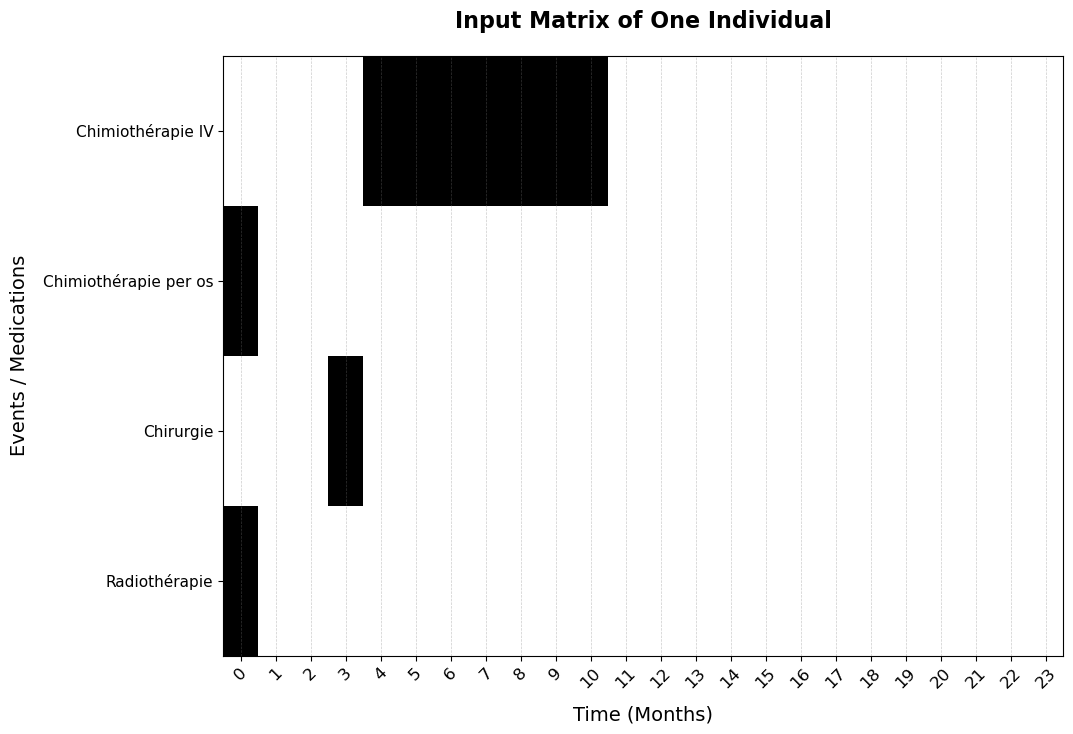

In [20]:
patient_index = int(patients_complets[0])
print(f"Patient utilisé pour la visualisation : {patient_index}")
plot_input_matrix(tensor, id=patient_index, labels=tca.label_to_encoded, time_unit='Months')

La matrice du patient n°8 montre bien la nature multidimensionnelle des données : plusieurs traitements peuvent être actifs simultanément à un même instant. On observe ici qu'au mois 0 par exemple, on a à la fois une chimiothérapie per os et une radiothérapie.

## 4. Exploration des hyperparamètres de SWoTTeD

L'objectif de cette section est d'identifier une configuration d'hyperparamètres permettant d'obtenir simultanément une bonne qualité de reconstruction $\text{FIT}_X$ et des phénotypes temporels cliniquement interprétables.

La démarche est la suivante :
- on commence par explorer le rang $R$ et la taille de fenêtre $\omega$ sans early stopping ;
- on introduit ensuite l'early stopping et on réduit le taux d'apprentissage ;
- on fait enfin varier les termes de régularisation $\alpha$ et $\gamma$.

Pour chaque configuration, deux critères sont suivis :
- $\mathbf{FIT_X}$ : qualité globale de reconstruction des trajectoires ;
- **Diversité phénotypique** : degré de différenciation entre les phénotypes appris.

### 4.1. Variation du rang R et de la taille de fenêtre ω

On fait varier $R \in \{2, 3, 4, 5\}$ et $\omega \in \{2, 3, 4\}$, soit 12 configurations. Les autres hyperparamètres sont fixés : $\alpha = \gamma = 0{,}5$, lr $= 10^{-2}$,
200 epochs, sans early stopping.

Le critère de comparaison retenu est le meilleur $\text{FIT}_X$ approximé atteint au cours de l'entraînement, et non sa valeur à la dernière epoch, en raison de l'instabilité observée en fin d'entraînement.

In [ ]:
n_epochs = 200
ranks    = [2, 3, 4, 5]
windows  = [2, 3, 4]
s        = 0.5
ns       = 0.5
lr       = 1e-2
results1 = []

for r in ranks:
    for w in windows:
        results1.append(run_swotted_trial(
            timed_event_structure, r, w,
            reg_ns=ns, reg_s=s, lr=lr, n_epochs=n_epochs,
            early_stopping=False,
        ))

results_df1 = build_results_df(results1)
display(results_df1.drop(columns='tca_trial'))

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



rank=2, twl=2, reg_ns=0.5, reg_s=0.5, learning_rate=0.01
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 24     | n/a   | n/a  
--------------------------------------


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 : - train_loss_Ph: 15.412683 - train_loss_W: 29.888893 - train_loss_total: 45.301577 - duration: 3.93s - FIT metric: 0.1513
    checkpoint: New best FIT metric = 0.1513 at epoch 1.
Epoch 2/200 : - train_loss_Ph: 18.504469 - train_loss_W: 32.454155 - train_loss_total: 50.958624 - duration: 3.82s
Epoch 3/200 : - train_loss_Ph: 16.136862 - train_loss_W: 29.676945 - train_loss_total: 45.813807 - duration: 4.15s
Epoch 4/200 : - train_loss_Ph: 14.597366 - train_loss_W: 27.828072 - train_loss_total: 42.425438 - duration: 3.73s
Epoch 5/200 : - train_loss_Ph: 14.913898 - train_loss_W: 27.706436 - train_loss_total: 42.620334 - duration: 3.77s
Epoch 6/200 : - train_loss_Ph: 14.519921 - train_loss_W: 26.909037 - train_loss_total: 41.428958 - duration: 2.93s
Epoch 7/200 : - train_loss_Ph: 14.445260 - train_loss_W: 26.429588 - train_loss_total: 40.874848 - duration: 3.10s
Epoch 8/200 : - train_loss_Ph: 21.706892 - train_loss_W: 32.829216 - train_loss_total: 54.536108 - duration: 3.02s
Ep

La configuration $R=4$, $\omega=2$ obtient le meilleur $\text{FIT}_X$ max approximé, aux alentours de $0{,}5$, mais on peut voir qu'à la fin de l'entraînement, $\text{FIT}_X$ devient très négative.
On visualise ses phénotypes, sa courbe d'entraînement et la reconstruction d'un patient.

In [ ]:
best1 = results_df1.iloc[0]
tca_best1 = best1['tca_trial']

# Phénotypes et reconstruction
tca_best1.analyzer.get_decomposition_results(
    labels=tca.label_to_encoded,
    id=8,
    time_unit='Months',
)

# Courbe d'entraînement
plot_training_history(best1)

# Diversité phénotypique
print_diversity(best1)

On observe que $\text{FIT}_X$ augmente jusqu'à un maximum autour de l'epoch 60 à eviron $0{,}5$, puis se dégrade progressivement jusqu'à devenir négative en fin d'entraînement, alors que la loss continue de décroître, mais on observe quelques pics qui pourrait être un signe que notre taux d'apprentissage est trop élevé. Ce comportement, ainsi que la forte hétérogénéité des reconstructions individuelles, nous conduit à introduire un mécanisme d'early stopping et à réduire le taux d'apprentissage.

Toutefois, malgré les mauvais résultats pour $\text{FIT}_X$, on observe que nos phénotypes sont très marqués et interprétables et la reconstruction du patient n°8 est très bonne

On remarque aussi que notre diversité des phénotypes est très bonne, elle est égale à 1, tous nos phénotypes sont bien distincts.

In [ ]:
tca_best1.analyzer.get_decomposition_results(
    labels=tca.label_to_encoded,
    id=20,
    time_unit='Months',
)

Toutefois, quand on observe la reconstruction d'un autre patient, celle-ci est beaucoup moins bonne et explique la mauvaise fit metric.

### 4.2. Réduction du taux d'apprentissage avec early stopping

On conserve la configuration $R=4$, $\omega=2$ et on teste deux taux d'apprentissage plus faibles : $5 \times 10^{-5}$ et $10^{-4}$, avec early stopping activé sur 500 epochs.

In [ ]:
n_epochs       = 500
r, w           = 4, 2
s, ns          = 0.5, 0.5
learning_rates = [5e-5, 1e-4]
results2       = []

for lr in learning_rates:
    results2.append(run_swotted_trial(
        timed_event_structure, r, w,
        reg_ns=ns, reg_s=s, lr=lr, n_epochs=n_epochs,
        early_stopping=True,
    ))

results_df2 = build_results_df(results2)
display(results_df2.drop(columns='tca_trial'))

Le taux $10^{-4}$ est préférable : il atteint un meilleur $\text{FIT}_X$ en moins d'epochs et en moins de temps.
Toutefois, dans ce cas, $\text{FIT}_X$ est très petit, même si à la fin de l'entraînement, $\text{FIT}_X$ est au dessus de 0 contrairement au cas précédent, notre $\text{FIT}_X$ max est de seulement $0{,}013$
On visualise les résultats pour cette configuration.


In [ ]:
best2 = results_df2.iloc[0]
tca_best2 = best2['tca_trial']

tca_best2.analyzer.get_decomposition_results(
    labels=tca.label_to_encoded,
    id=8,
    time_unit='Months',
)

plot_training_history(best2)
print_diversity(best2)

La réduction du taux d'apprentissage stabilise l'entraînement :  $\text{FIT}_X$ ne se dégrade plus en fin d'entraînement, on part d'un $\text{FIT}_X$ négatif au départ avant d'atteindre un maximum aux alentours de 100 epochs, puis de se stabiliser jusqu'à la fin de l'entraînement. 
Cependant, les phénotypes obtenus sont très peu marqués et quasi identiques, ce qui se confirme par une diversité très faible.

Cela nous conduit à explorer les termes de régularisation.

### 4.3. Ajustement des termes de régularisation : faibles pénalités

On fait varier conjointement $\alpha$ et $\gamma$ sur de très petites valeurs, en conservant $R=4$, $\omega=2$, lr $= 10^{-4}$, avec early stopping.

L'hypothèse est qu'une pénalité trop forte empêche les activations des phénotypes : réduire $\alpha$ et $\gamma$ devrait permettre des phénotypes plus denses et plus marqués, et donc plus interpétables.

In [ ]:
n_epochs       = 500
r, w           = 4, 2
lr             = 1e-4
sparsities     = [1e-5, 5e-3, 1e-1]
non_successions = [1e-5, 5e-3, 1e-1]
results3       = []

for ns in non_successions:
    for s in sparsities:
        results3.append(run_swotted_trial(
            timed_event_structure, r, w,
            reg_ns=ns, reg_s=s, lr=lr, n_epochs=n_epochs,
            early_stopping=True,
        ))

results_df3 = build_results_df(results3)
display(results_df3.drop(columns='tca_trial'))

La meilleure configuration est donc celle avec $\alpha = \gamma = 5 \times 10^{-3}$, on atteint une $\text{FIT}_X$ finale de $0{,}048$, ce qui est très petit, mais meilleur que les résultats obtenus précedemment.

In [ ]:
best3 = results_df3.iloc[0]

best3['tca_trial'].analyzer.get_decomposition_results(
    labels=tca.label_to_encoded,
    id=8,
    time_unit='Months',
)

plot_training_history(best3)
print_diversity(best3)

Malgré une légère amélioration de $\text{FIT}_X$, les phénotypes restent très peu activés et quasi identiques entre eux. Les valeurs de FIT_X sont très homogènes entre les 9 configurations, ce qui suggère que le modèle converge vers le même type de solution quelle que soit la combinaison de $\alpha$ et $\gamma$ testée.

### 4.4. Ajustement des termes de régularisation — fortes pénalités

On explore maintenant l'effet de fortes pénalités en trois sous-expériences :
- les deux termes simultanément élevés ($\alpha = \gamma = 0{,}99$) ;
- grand $\gamma$, petit $\alpha$ ($\alpha = 10^{-5}$, $\gamma \in \{0{,}70, 0{,}80, 0{,}90, 0{,}95, 0{,}99\}$) ;
- grand $\alpha$, petit $\gamma$ ($\gamma = 10^{-5}$, $\alpha \in \{0{,}70, 0{,}80, 0{,}90, 0{,}95, 0{,}99\}$).

#### Les deux termes simultanément élevés

In [ ]:
results4 = [run_swotted_trial(
    timed_event_structure, r=4, w=2,
    reg_ns=0.99, reg_s=0.99, lr=1e-4, n_epochs=500,
    early_stopping=True,
)]

results_df4 = build_results_df(results4)
display(results_df4.drop(columns='tca_trial'))

plot_training_history(results_df4.iloc[0])
print_diversity(results_df4.iloc[0])

#### Grand γ, petit α

In [ ]:
n_epochs        = 500
non_successions = [0.70, 0.80, 0.90, 0.95, 0.99]
results5        = []

for ns in non_successions:
    results5.append(run_swotted_trial(
        timed_event_structure, r=4, w=2,
        reg_ns=ns, reg_s=1e-5, lr=1e-4, n_epochs=n_epochs,
        early_stopping=True,
    ))

results_df5 = build_results_df(results5)
display(results_df5.drop(columns='tca_trial'))

best5 = results_df5.iloc[0]
best5['tca_trial'].analyzer.get_decomposition_results(
    labels=tca.label_to_encoded, id=8, time_unit='Months',
)
plot_training_history(best5)
print_diversity(best5)

#### Grand α, petit γ

In [ ]:
n_epochs   = 500
sparsities = [0.70, 0.80, 0.90, 0.95, 0.99]
results6   = []

for s in sparsities:
    results6.append(run_swotted_trial(
        timed_event_structure, r=4, w=2,
        reg_ns=1e-5, reg_s=s, lr=1e-4, n_epochs=n_epochs,
        early_stopping=True,
    ))

results_df6 = build_results_df(results6)
display(results_df6.drop(columns='tca_trial'))

best6 = results_df6.iloc[0]
best6['tca_trial'].analyzer.get_decomposition_results(
    labels=tca.label_to_encoded, id=8, time_unit='Months',
)
plot_training_history(best6)
print_diversity(best6)

La configuration $\alpha=0{,}70$, $\gamma=10^{-5}$ obtient le meilleur $\text{FIT}_X$ parmi toutes les configurations testées avec lr $= 10^{-4}$ ($\text{FIT}_X = 0{,}051$).
Cependant, les phénotypes restent peu différenciés, ce qui se confirme par une diversité très mauvaise. 

## 5. Clustering sur les intensités des phénotypes

L'objectif final de la décomposition SWoTTeD est de regrouper les patients en clusters cliniquement interprétables. Une fois les phénotypes appris, chaque patient $k$ est résumé par un vecteur d'intensités de taille $R$, obtenu en sommant les activations de sa matrice $W^{(k)}$ sur toute la durée du suivi, puis en normalisant. C'est sur cette représentation compacte que le clustering est appliqué.

Comme montré en section 4, la configuration produisant les phénotypes les plus distincts est celle de l'étape 4.1 ($R=4$, $\omega=2$, $\alpha=\gamma=0{,}5$, lr $=10^{-2}$, sans early stopping, $\text{div} = 1{,}000$). Bien que sa $\text{FIT}_X$ soit instable et négative en fin d'entraînement, c'est la seule configuration pour laquelle les phénotypes capturent des combinaisons d'événements réellement distinctes.

### 5.1. Récupération de la configuration de référence

In [ ]:
best_pheno_config = results_df1[
    (results_df1['rank'] == 4) & (results_df1['time_window_length'] == 2)
].iloc[0]

tca_best_pheno = best_pheno_config['tca_trial']

print(f"Configuration retenue :")
print(f"  R={best_pheno_config['rank']}, ω={best_pheno_config['time_window_length']}")
print(f"  α={best_pheno_config['reg_term_s']}, γ={best_pheno_config['reg_term_ns']}")
print(f"  lr={best_pheno_config['learning_rate']}")
print(f"  best_fit_metric  = {best_pheno_config['best_fit_metric']:.4f} "
      f"(epoch {best_pheno_config['best_fit_epoch']})")
print(f"  final_fit_metric = {best_pheno_config['final_fit_metric']:.4f}")
print(f"  div(P)           = 1.000 (phénotypes parfaitement orthogonaux)")

### 5.2. Visualisation des phénotypes retenus

In [ ]:
tca_best_pheno.analyzer.get_decomposition_results(
    labels=tca.label_to_encoded,
    id=8,
    time_unit='Months',
)

In [ ]:
from sklearn.preprocessing import StandardScaler

ph_intensity = tca_best_pheno.analyzer.to_phenotype_intensity(scaler=StandardScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

In [ ]:
distance_matrix = tca_best_pheno.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca_best_pheno.hierarchical_clustering(distance_matrix)

# Visualisations standard du package
tca_best_pheno.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca_best_pheno.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca_best_pheno.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca_best_pheno.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')